# Differentiation: The Heart of Calculus

## What is a Derivative?

The derivative measures **instantaneous rate of change** - how fast something is changing at a precise moment.

**Three Equivalent Views**:

1. **Geometric**: Slope of the tangent line to the curve
2. **Physical**: Instantaneous velocity (rate of change of position)
3. **Mathematical**: Limit of average rate of change as interval shrinks to zero

### Formal Definition

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

Alternative form:
$$f'(a) = \lim_{x \to a} \frac{f(x) - f(a)}{x - a}$$

**Notation**:
- $f'(x)$ - Lagrange notation
- $\frac{df}{dx}$ or $\frac{d}{dx}f(x)$ - Leibniz notation
- $Df(x)$ - Euler notation
- $\dot{f}$ - Newton notation (for time derivatives)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyArrowPatch
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12

## 1. Geometric Understanding: From Secant to Tangent

The derivative is the limit of secant line slopes as the points get closer together.

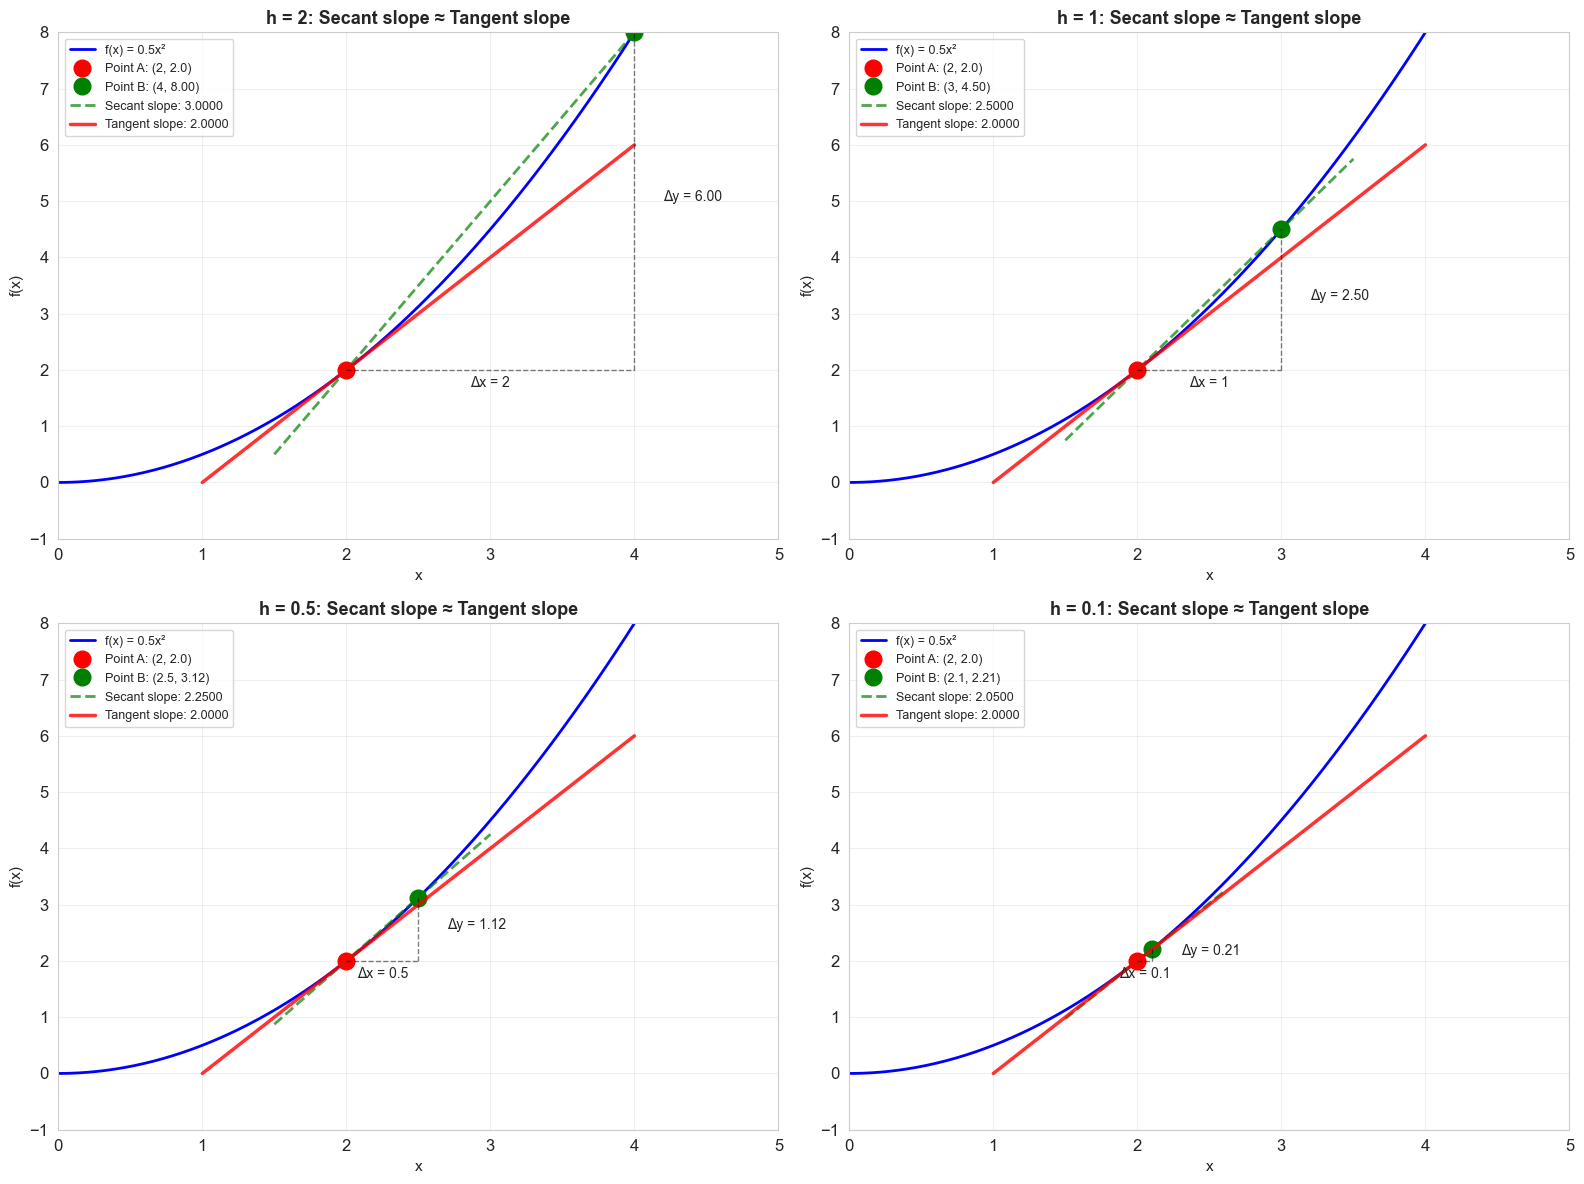

As h → 0, the secant line slope approaches the tangent line slope!

At x = 2:
  True derivative (tangent slope): f'(2) = 2

  Secant slopes:
    h =  2.000  →  slope = 3.000000
    h =  1.000  →  slope = 2.500000
    h =  0.500  →  slope = 2.250000
    h =  0.100  →  slope = 2.050000
    h =  0.010  →  slope = 2.005000
    h =  0.001  →  slope = 2.000500

  Limit as h→0: 2


In [2]:
# Visualize secant lines approaching tangent line
def f(x):
    return 0.5 * x**2

def df(x):
    return x  # Derivative of 0.5x²

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

x = np.linspace(-1, 5, 1000)
y = f(x)

a = 2  # Point of interest
h_values = [2, 1, 0.5, 0.1]  # Different h values

for idx, (ax, h) in enumerate(zip(axes.flat, h_values)):
    # Plot function
    ax.plot(x, y, 'b-', linewidth=2, label='f(x) = 0.5x²')
    
    # Plot points
    ax.plot(a, f(a), 'ro', markersize=12, label=f'Point A: ({a}, {f(a)})')
    ax.plot(a+h, f(a+h), 'go', markersize=12, label=f'Point B: ({a+h}, {f(a+h):.2f})')
    
    # Secant line
    slope_secant = (f(a+h) - f(a)) / h
    x_secant = np.linspace(a-0.5, a+h+0.5, 100)
    y_secant = f(a) + slope_secant * (x_secant - a)
    ax.plot(x_secant, y_secant, 'g--', linewidth=2, alpha=0.7, 
            label=f'Secant slope: {slope_secant:.4f}')
    
    # True tangent line
    slope_tangent = df(a)
    x_tangent = np.linspace(a-1, a+2, 100)
    y_tangent = f(a) + slope_tangent * (x_tangent - a)
    ax.plot(x_tangent, y_tangent, 'r-', linewidth=2.5, alpha=0.8, 
            label=f'Tangent slope: {slope_tangent:.4f}')
    
    # Draw rise and run
    ax.plot([a+h, a+h], [f(a), f(a+h)], 'k--', linewidth=1, alpha=0.5)
    ax.plot([a, a+h], [f(a), f(a)], 'k--', linewidth=1, alpha=0.5)
    ax.text(a+h/2, f(a)-0.3, f'Δx = {h}', fontsize=10, ha='center')
    ax.text(a+h+0.2, (f(a)+f(a+h))/2, f'Δy = {f(a+h)-f(a):.2f}', fontsize=10)
    
    ax.set_title(f'h = {h}: Secant slope ≈ Tangent slope', fontsize=13, fontweight='bold')
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('f(x)', fontsize=11)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 5)
    ax.set_ylim(-1, 8)

plt.tight_layout()
plt.show()

print("As h → 0, the secant line slope approaches the tangent line slope!")
print(f"\nAt x = {a}:")
print(f"  True derivative (tangent slope): f'({a}) = {df(a)}")
print(f"\n  Secant slopes:")
for h in [2, 1, 0.5, 0.1, 0.01, 0.001]:
    secant_slope = (f(a+h) - f(a)) / h
    print(f"    h = {h:6.3f}  →  slope = {secant_slope:.6f}")
print(f"\n  Limit as h→0: {df(a)}")

## 2. Computing Derivatives from the Definition

Let's use the limit definition to find derivatives of basic functions.

In [3]:
print("=" * 70)
print("FINDING DERIVATIVES FROM THE DEFINITION")
print("=" * 70)

print("\nEXAMPLE 1: f(x) = x²")
print("-" * 70)
print("f'(x) = lim[h→0] [(x+h)² - x²] / h")
print("")
print("Step 1: Expand (x+h)²")
print("      = lim[h→0] [x² + 2xh + h² - x²] / h")
print("")
print("Step 2: Simplify")
print("      = lim[h→0] [2xh + h²] / h")
print("")
print("Step 3: Factor out h")
print("      = lim[h→0] h(2x + h) / h")
print("      = lim[h→0] (2x + h)")
print("")
print("Step 4: Take the limit")
print("      = 2x + 0 = 2x")
print("")
print("Result: d/dx(x²) = 2x")

print("\n" + "=" * 70)
print("\nEXAMPLE 2: f(x) = √x")
print("-" * 70)
print("f'(x) = lim[h→0] [√(x+h) - √x] / h")
print("")
print("Step 1: Multiply by conjugate")
print("      = lim[h→0] [√(x+h) - √x] · [√(x+h) + √x] / [h(√(x+h) + √x)]")
print("")
print("Step 2: Simplify numerator (difference of squares)")
print("      = lim[h→0] [(x+h) - x] / [h(√(x+h) + √x)]")
print("      = lim[h→0] h / [h(√(x+h) + √x)]")
print("")
print("Step 3: Cancel h")
print("      = lim[h→0] 1 / (√(x+h) + √x)")
print("")
print("Step 4: Take the limit")
print("      = 1 / (√x + √x) = 1 / (2√x)")
print("")
print("Result: d/dx(√x) = 1/(2√x) = (1/2)x^(-1/2)")

print("\n" + "=" * 70)

FINDING DERIVATIVES FROM THE DEFINITION

EXAMPLE 1: f(x) = x²
----------------------------------------------------------------------
f'(x) = lim[h→0] [(x+h)² - x²] / h

Step 1: Expand (x+h)²
      = lim[h→0] [x² + 2xh + h² - x²] / h

Step 2: Simplify
      = lim[h→0] [2xh + h²] / h

Step 3: Factor out h
      = lim[h→0] h(2x + h) / h
      = lim[h→0] (2x + h)

Step 4: Take the limit
      = 2x + 0 = 2x

Result: d/dx(x²) = 2x


EXAMPLE 2: f(x) = √x
----------------------------------------------------------------------
f'(x) = lim[h→0] [√(x+h) - √x] / h

Step 1: Multiply by conjugate
      = lim[h→0] [√(x+h) - √x] · [√(x+h) + √x] / [h(√(x+h) + √x)]

Step 2: Simplify numerator (difference of squares)
      = lim[h→0] [(x+h) - x] / [h(√(x+h) + √x)]
      = lim[h→0] h / [h(√(x+h) + √x)]

Step 3: Cancel h
      = lim[h→0] 1 / (√(x+h) + √x)

Step 4: Take the limit
      = 1 / (√x + √x) = 1 / (2√x)

Result: d/dx(√x) = 1/(2√x) = (1/2)x^(-1/2)



## 3. Basic Derivative Rules

These rules let us avoid using the limit definition every time!

### Power Rule
$$\frac{d}{dx}x^n = nx^{n-1}$$

### Constant Multiple Rule
$$\frac{d}{dx}[cf(x)] = c\frac{d}{dx}f(x)$$

### Sum/Difference Rule
$$\frac{d}{dx}[f(x) \pm g(x)] = \frac{d}{dx}f(x) \pm \frac{d}{dx}g(x)$$

### Common Functions
$$\frac{d}{dx}(c) = 0$$
$$\frac{d}{dx}(e^x) = e^x$$
$$\frac{d}{dx}(\ln x) = \frac{1}{x}$$
$$\frac{d}{dx}(\sin x) = \cos x$$
$$\frac{d}{dx}(\cos x) = -\sin x$$
$$\frac{d}{dx}(\tan x) = \sec^2 x$$

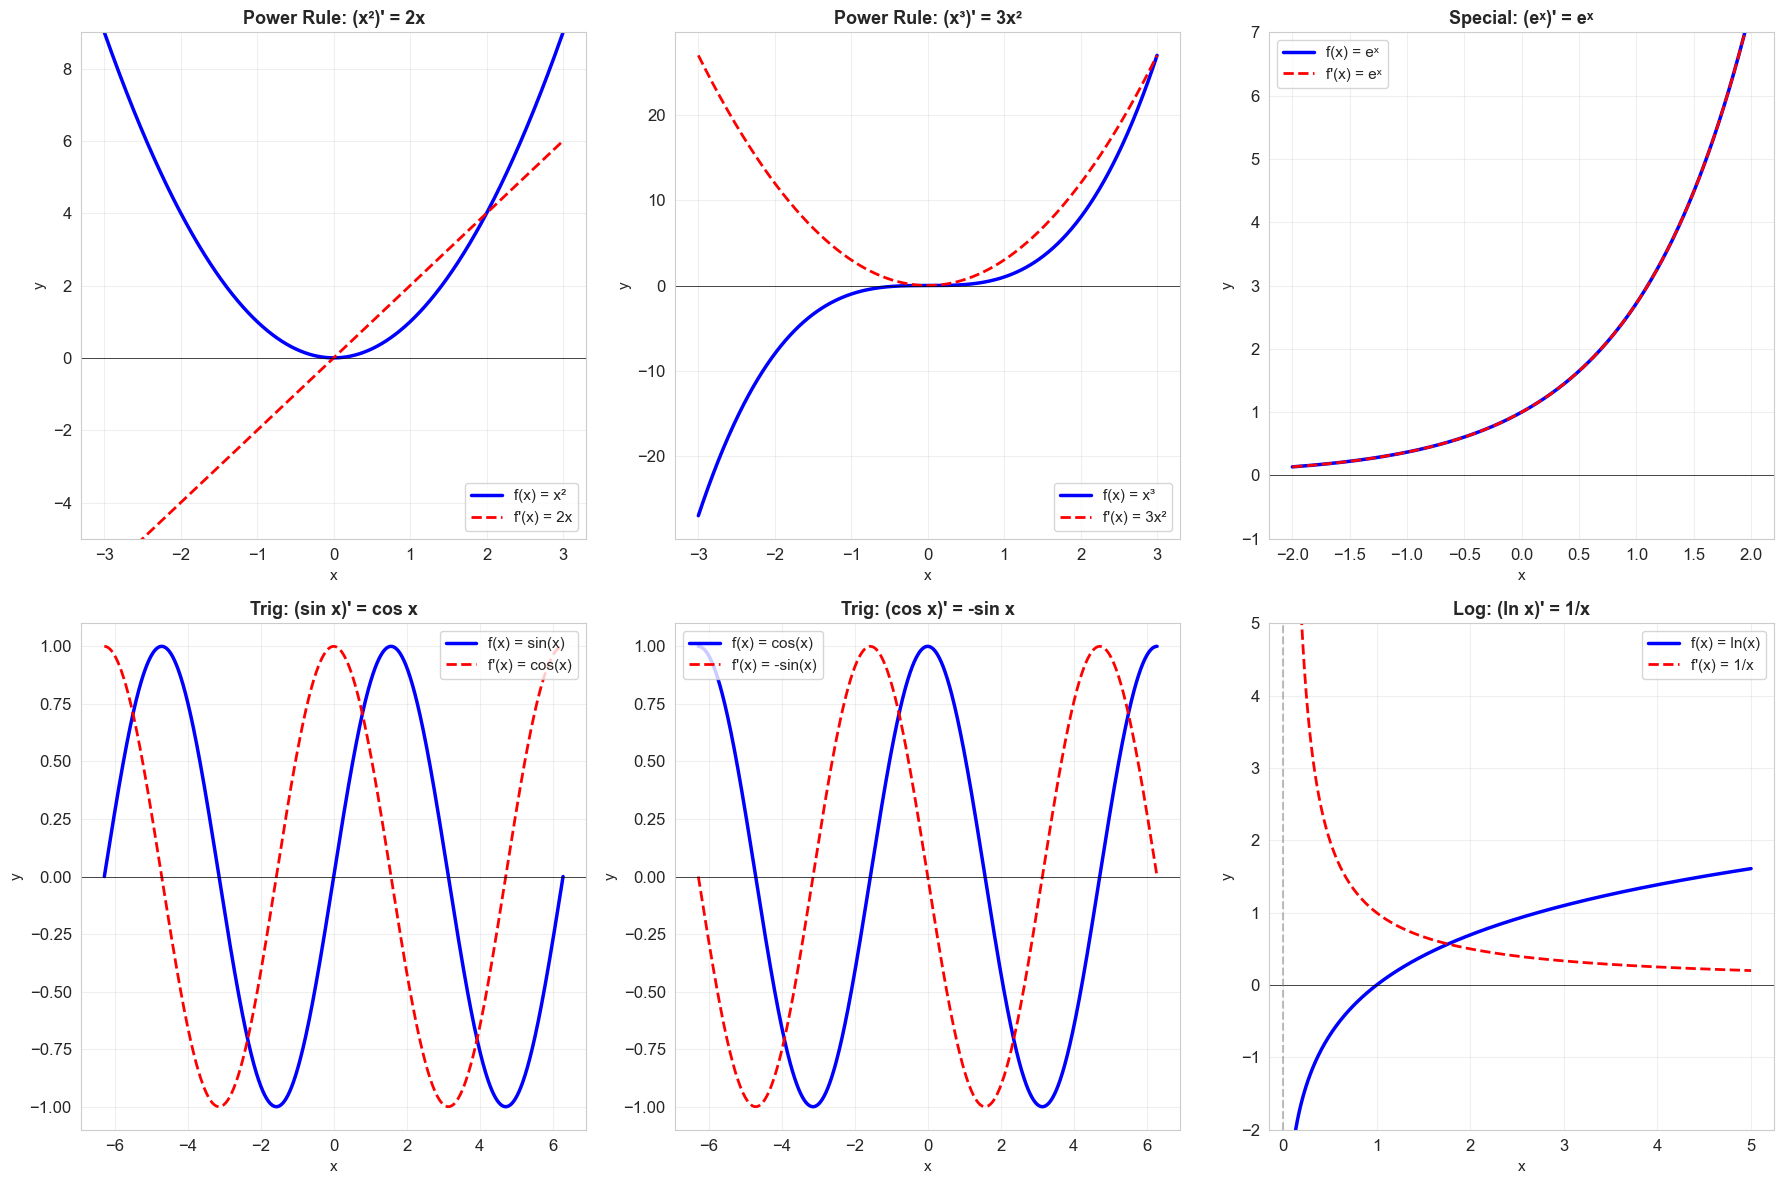

Notice:
  • Where f is increasing, f' > 0
  • Where f is decreasing, f' < 0
  • Where f has max/min, f' = 0
  • Steeper slope → larger |f'|


In [4]:
# Visualize function and derivative together
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

x = np.linspace(-3, 3, 1000)

# f(x) = x²,  f'(x) = 2x
axes[0, 0].plot(x, x**2, 'b-', linewidth=2.5, label='f(x) = x²')
axes[0, 0].plot(x, 2*x, 'r--', linewidth=2, label="f'(x) = 2x")
axes[0, 0].axhline(y=0, color='black', linewidth=0.5)
axes[0, 0].set_title('Power Rule: (x²)\' = 2x', fontsize=13, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim(-5, 9)

# f(x) = x³,  f'(x) = 3x²
axes[0, 1].plot(x, x**3, 'b-', linewidth=2.5, label='f(x) = x³')
axes[0, 1].plot(x, 3*x**2, 'r--', linewidth=2, label="f'(x) = 3x²")
axes[0, 1].axhline(y=0, color='black', linewidth=0.5)
axes[0, 1].set_title('Power Rule: (x³)\' = 3x²', fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# f(x) = eˣ,  f'(x) = eˣ
x_exp = np.linspace(-2, 2, 1000)
axes[0, 2].plot(x_exp, np.exp(x_exp), 'b-', linewidth=2.5, label='f(x) = eˣ')
axes[0, 2].plot(x_exp, np.exp(x_exp), 'r--', linewidth=2, label="f'(x) = eˣ")
axes[0, 2].axhline(y=0, color='black', linewidth=0.5)
axes[0, 2].set_title('Special: (eˣ)\' = eˣ', fontsize=13, fontweight='bold')
axes[0, 2].legend(fontsize=11)
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].set_ylim(-1, 7)

# f(x) = sin(x),  f'(x) = cos(x)
x_trig = np.linspace(-2*np.pi, 2*np.pi, 1000)
axes[1, 0].plot(x_trig, np.sin(x_trig), 'b-', linewidth=2.5, label='f(x) = sin(x)')
axes[1, 0].plot(x_trig, np.cos(x_trig), 'r--', linewidth=2, label="f'(x) = cos(x)")
axes[1, 0].axhline(y=0, color='black', linewidth=0.5)
axes[1, 0].set_title('Trig: (sin x)\' = cos x', fontsize=13, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# f(x) = cos(x),  f'(x) = -sin(x)
axes[1, 1].plot(x_trig, np.cos(x_trig), 'b-', linewidth=2.5, label='f(x) = cos(x)')
axes[1, 1].plot(x_trig, -np.sin(x_trig), 'r--', linewidth=2, label="f'(x) = -sin(x)")
axes[1, 1].axhline(y=0, color='black', linewidth=0.5)
axes[1, 1].set_title('Trig: (cos x)\' = -sin x', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

# f(x) = ln(x),  f'(x) = 1/x
x_ln = np.linspace(0.1, 5, 1000)
axes[1, 2].plot(x_ln, np.log(x_ln), 'b-', linewidth=2.5, label='f(x) = ln(x)')
axes[1, 2].plot(x_ln, 1/x_ln, 'r--', linewidth=2, label="f'(x) = 1/x")
axes[1, 2].axhline(y=0, color='black', linewidth=0.5)
axes[1, 2].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 2].set_title('Log: (ln x)\' = 1/x', fontsize=13, fontweight='bold')
axes[1, 2].legend(fontsize=11)
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].set_ylim(-2, 5)

for ax in axes.flat:
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('y', fontsize=11)

plt.tight_layout()
plt.show()

print("Notice:")
print("  • Where f is increasing, f' > 0")
print("  • Where f is decreasing, f' < 0")
print("  • Where f has max/min, f' = 0")
print("  • Steeper slope → larger |f'|")

## 4. Product, Quotient, and Chain Rules

### Product Rule
$$\frac{d}{dx}[f(x)g(x)] = f'(x)g(x) + f(x)g'(x)$$

**Mnemonic**: "First times derivative of second, plus second times derivative of first"

### Quotient Rule
$$\frac{d}{dx}\left[\frac{f(x)}{g(x)}\right] = \frac{f'(x)g(x) - f(x)g'(x)}{[g(x)]^2}$$

**Mnemonic**: "Low d-high minus high d-low, over low squared"

### Chain Rule
$$\frac{d}{dx}[f(g(x))] = f'(g(x)) \cdot g'(x)$$

Or in Leibniz notation:
$$\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}$$

**Most important rule** - used constantly!

In [5]:
print("=" * 70)
print("PRODUCT, QUOTIENT, AND CHAIN RULE EXAMPLES")
print("=" * 70)

print("\n1. PRODUCT RULE: d/dx[f·g] = f'g + fg'")
print("-" * 70)
print("Example: f(x) = x² · sin(x)")
print("  f(x) = x²,    f'(x) = 2x")
print("  g(x) = sin(x), g'(x) = cos(x)")
print("")
print("  d/dx[x²·sin(x)] = (2x)·sin(x) + x²·cos(x)")
print("                  = 2x·sin(x) + x²·cos(x)")

# Verify numerically
x_test = 1.0
h = 0.0001
f = lambda x: x**2 * np.sin(x)
derivative_numerical = (f(x_test + h) - f(x_test)) / h
derivative_formula = 2*x_test*np.sin(x_test) + x_test**2*np.cos(x_test)
print(f"\n  Verification at x = {x_test}:")
print(f"    Numerical:  {derivative_numerical:.6f}")
print(f"    Formula:    {derivative_formula:.6f}")

print("\n" + "=" * 70)
print("\n2. QUOTIENT RULE: d/dx[f/g] = (f'g - fg')/g²")
print("-" * 70)
print("Example: f(x) = x/(x²+1)")
print("  f(x) = x,      f'(x) = 1")
print("  g(x) = x²+1,   g'(x) = 2x")
print("")
print("  d/dx[x/(x²+1)] = [(1)(x²+1) - (x)(2x)] / (x²+1)²")
print("                 = [x²+1 - 2x²] / (x²+1)²")
print("                 = (1 - x²) / (x²+1)²")

# Verify numerically
x_test = 2.0
f = lambda x: x / (x**2 + 1)
derivative_numerical = (f(x_test + h) - f(x_test)) / h
derivative_formula = (1 - x_test**2) / (x_test**2 + 1)**2
print(f"\n  Verification at x = {x_test}:")
print(f"    Numerical:  {derivative_numerical:.6f}")
print(f"    Formula:    {derivative_formula:.6f}")

print("\n" + "=" * 70)
print("\n3. CHAIN RULE: d/dx[f(g(x))] = f'(g(x))·g'(x)")
print("-" * 70)
print("Example: f(x) = sin(x²)")
print("  Outer function: f(u) = sin(u),  f'(u) = cos(u)")
print("  Inner function: u = g(x) = x²,  g'(x) = 2x")
print("")
print("  d/dx[sin(x²)] = cos(x²)·(2x)")
print("                = 2x·cos(x²)")

# Verify numerically
x_test = 1.0
f = lambda x: np.sin(x**2)
derivative_numerical = (f(x_test + h) - f(x_test)) / h
derivative_formula = 2*x_test*np.cos(x_test**2)
print(f"\n  Verification at x = {x_test}:")
print(f"    Numerical:  {derivative_numerical:.6f}")
print(f"    Formula:    {derivative_formula:.6f}")

print("\n" + "=" * 70)
print("\n4. COMBINING RULES: f(x) = e^(x²)·cos(3x)")
print("-" * 70)
print("Step 1: Recognize this needs Product Rule")
print("        f(x) = [e^(x²)]·[cos(3x)]")
print("")
print("Step 2: Find derivatives (need Chain Rule for each!)")
print("        d/dx[e^(x²)] = e^(x²)·2x   (chain rule)")
print("        d/dx[cos(3x)] = -sin(3x)·3  (chain rule)")
print("")
print("Step 3: Apply Product Rule")
print("        f'(x) = [2x·e^(x²)]·cos(3x) + e^(x²)·[-3sin(3x)]")
print("              = e^(x²)[2x·cos(3x) - 3sin(3x)]")

print("\n" + "=" * 70)

PRODUCT, QUOTIENT, AND CHAIN RULE EXAMPLES

1. PRODUCT RULE: d/dx[f·g] = f'g + fg'
----------------------------------------------------------------------
Example: f(x) = x² · sin(x)
  f(x) = x²,    f'(x) = 2x
  g(x) = sin(x), g'(x) = cos(x)

  d/dx[x²·sin(x)] = (2x)·sin(x) + x²·cos(x)
                  = 2x·sin(x) + x²·cos(x)

  Verification at x = 1.0:
    Numerical:  2.223394
    Formula:    2.223244


2. QUOTIENT RULE: d/dx[f/g] = (f'g - fg')/g²
----------------------------------------------------------------------
Example: f(x) = x/(x²+1)
  f(x) = x,      f'(x) = 1
  g(x) = x²+1,   g'(x) = 2x

  d/dx[x/(x²+1)] = [(1)(x²+1) - (x)(2x)] / (x²+1)²
                 = [x²+1 - 2x²] / (x²+1)²
                 = (1 - x²) / (x²+1)²

  Verification at x = 2.0:
    Numerical:  -0.119998
    Formula:    -0.120000


3. CHAIN RULE: d/dx[f(g(x))] = f'(g(x))·g'(x)
----------------------------------------------------------------------
Example: f(x) = sin(x²)
  Outer function: f(u) = sin(u),  f'(u) =

## 5. Implicit Differentiation

When you can't easily solve for $y$ in terms of $x$, differentiate both sides with respect to $x$.

**Key**: Remember $\frac{d}{dx}(y) = \frac{dy}{dx}$ and use the chain rule!

**Example**: Circle $x^2 + y^2 = 25$

$$\frac{d}{dx}(x^2 + y^2) = \frac{d}{dx}(25)$$
$$2x + 2y\frac{dy}{dx} = 0$$
$$\frac{dy}{dx} = -\frac{x}{y}$$

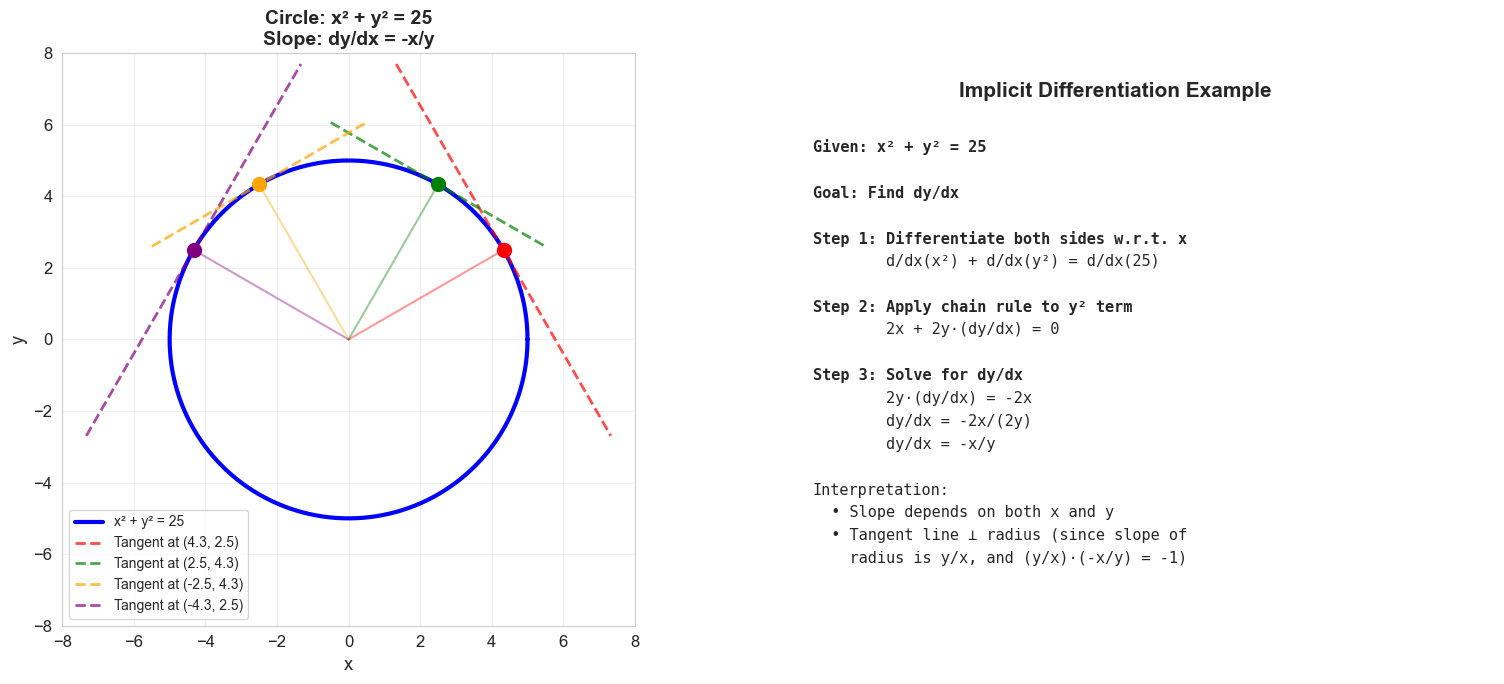

In [6]:
# Visualize implicit differentiation on a circle
theta = np.linspace(0, 2*np.pi, 1000)
r = 5
x_circle = r * np.cos(theta)
y_circle = r * np.sin(theta)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot circle
ax1.plot(x_circle, y_circle, 'b-', linewidth=3, label='x² + y² = 25')

# Plot tangent lines at several points
angles = [np.pi/6, np.pi/3, 2*np.pi/3, 5*np.pi/6]
colors = ['red', 'green', 'orange', 'purple']

for angle, color in zip(angles, colors):
    x_p = r * np.cos(angle)
    y_p = r * np.sin(angle)
    
    # Slope from implicit differentiation: dy/dx = -x/y
    if abs(y_p) > 0.1:  # Avoid division by zero
        slope = -x_p / y_p
        
        # Tangent line
        x_tang = np.linspace(x_p - 3, x_p + 3, 100)
        y_tang = y_p + slope * (x_tang - x_p)
        
        ax1.plot(x_tang, y_tang, color=color, linewidth=2, alpha=0.7, linestyle='--',
                label=f'Tangent at ({x_p:.1f}, {y_p:.1f})')
        ax1.plot(x_p, y_p, 'o', color=color, markersize=10)
        
        # Draw radius (perpendicular to tangent)
        ax1.plot([0, x_p], [0, y_p], color=color, linewidth=1.5, alpha=0.4)

ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('x', fontsize=13)
ax1.set_ylabel('y', fontsize=13)
ax1.set_title('Circle: x² + y² = 25\nSlope: dy/dx = -x/y', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xlim(-8, 8)
ax1.set_ylim(-8, 8)

# Show the calculation
ax2.text(0.5, 0.95, 'Implicit Differentiation Example', transform=ax2.transAxes,
         fontsize=15, fontweight='bold', ha='center', va='top')

steps = [
    "Given: x² + y² = 25",
    "",
    "Goal: Find dy/dx",
    "",
    "Step 1: Differentiate both sides w.r.t. x",
    "        d/dx(x²) + d/dx(y²) = d/dx(25)",
    "",
    "Step 2: Apply chain rule to y² term",
    "        2x + 2y·(dy/dx) = 0",
    "",
    "Step 3: Solve for dy/dx",
    "        2y·(dy/dx) = -2x",
    "        dy/dx = -2x/(2y)",
    "        dy/dx = -x/y",
    "",
    "Interpretation:",
    "  • Slope depends on both x and y",
    "  • Tangent line ⊥ radius (since slope of",
    "    radius is y/x, and (y/x)·(-x/y) = -1)",
]

y_pos = 0.85
for step in steps:
    if step.startswith('Step') or step.startswith('Given') or step.startswith('Goal'):
        ax2.text(0.1, y_pos, step, transform=ax2.transAxes,
                 fontsize=11, fontweight='bold', va='top', family='monospace')
    else:
        ax2.text(0.1, y_pos, step, transform=ax2.transAxes,
                 fontsize=11, va='top', family='monospace')
    y_pos -= 0.04

ax2.axis('off')

plt.tight_layout()
plt.show()

## 6. Applications of Derivatives

### Finding Tangent Lines

Equation of tangent line at $(a, f(a))$:
$$y - f(a) = f'(a)(x - a)$$

### Critical Points

$c$ is a **critical point** if:
- $f'(c) = 0$ (horizontal tangent), or
- $f'(c)$ doesn't exist

Critical points are candidates for local max/min!

### First Derivative Test

- If $f' > 0$ on an interval, $f$ is **increasing**
- If $f' < 0$ on an interval, $f$ is **decreasing**
- If $f'$ changes from + to - at $c$, then $f$ has **local max** at $c$
- If $f'$ changes from - to + at $c$, then $f$ has **local min** at $c$

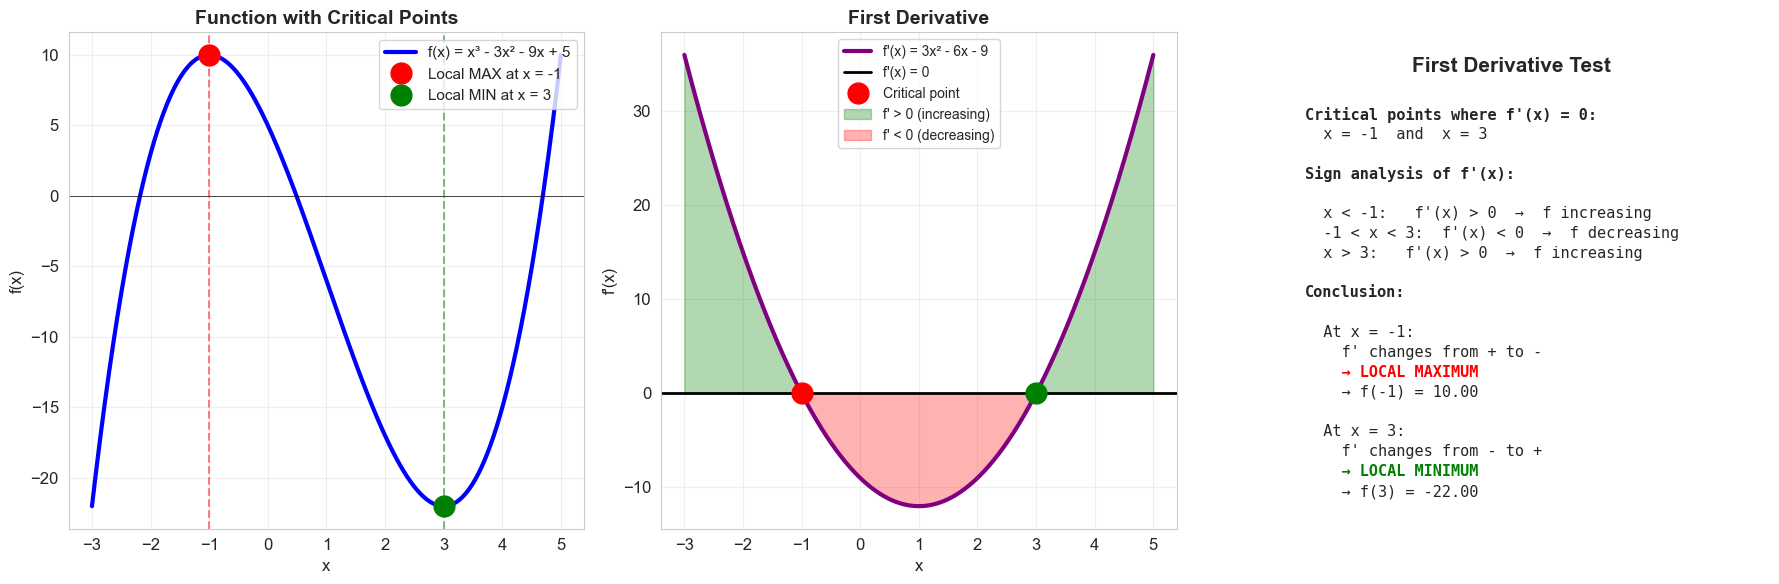

In [7]:
# Visualize critical points and first derivative test
def f(x):
    return x**3 - 3*x**2 - 9*x + 5

def df(x):
    return 3*x**2 - 6*x - 9

x = np.linspace(-3, 5, 1000)
y = f(x)
dy = df(x)

# Find critical points: f'(x) = 0
# 3x² - 6x - 9 = 0
# x² - 2x - 3 = 0
# (x-3)(x+1) = 0
critical_points = [-1, 3]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Function with critical points
ax1.plot(x, y, 'b-', linewidth=3, label='f(x) = x³ - 3x² - 9x + 5')
ax1.plot(-1, f(-1), 'ro', markersize=15, label='Local MAX at x = -1')
ax1.plot(3, f(3), 'go', markersize=15, label='Local MIN at x = 3')
ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.axvline(x=-1, color='red', linestyle='--', alpha=0.5)
ax1.axvline(x=3, color='green', linestyle='--', alpha=0.5)
ax1.set_title('Function with Critical Points', fontsize=14, fontweight='bold')
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('f(x)', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Derivative
ax2.plot(x, dy, 'purple', linewidth=3, label="f'(x) = 3x² - 6x - 9")
ax2.axhline(y=0, color='black', linewidth=2, label="f'(x) = 0")
ax2.plot(-1, 0, 'ro', markersize=15, label='Critical point')
ax2.plot(3, 0, 'go', markersize=15)
ax2.fill_between(x[x < -1], 0, dy[x < -1], where=(dy[x < -1] > 0), 
                 alpha=0.3, color='green', label='f\' > 0 (increasing)')
ax2.fill_between(x[(x > -1) & (x < 3)], 0, dy[(x > -1) & (x < 3)], 
                 where=(dy[(x > -1) & (x < 3)] < 0), 
                 alpha=0.3, color='red', label='f\' < 0 (decreasing)')
ax2.fill_between(x[x > 3], 0, dy[x > 3], where=(dy[x > 3] > 0), 
                 alpha=0.3, color='green')
ax2.set_title('First Derivative', fontsize=14, fontweight='bold')
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel("f'(x)", fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Plot 3: Sign chart
ax3.text(0.5, 0.95, 'First Derivative Test', transform=ax3.transAxes,
         fontsize=15, fontweight='bold', ha='center', va='top')

info = [
    "Critical points where f'(x) = 0:",
    "  x = -1  and  x = 3",
    "",
    "Sign analysis of f'(x):",
    "",
    "  x < -1:   f'(x) > 0  →  f increasing",
    "  -1 < x < 3:  f'(x) < 0  →  f decreasing",
    "  x > 3:   f'(x) > 0  →  f increasing",
    "",
    "Conclusion:",
    "",
    "  At x = -1:",
    "    f' changes from + to -",
    "    → LOCAL MAXIMUM",
    f"    → f(-1) = {f(-1):.2f}",
    "",
    "  At x = 3:",
    "    f' changes from - to +",
    "    → LOCAL MINIMUM",
    f"    → f(3) = {f(3):.2f}",
]

y_pos = 0.85
for line in info:
    if 'Critical' in line or 'Sign' in line or 'Conclusion' in line:
        ax3.text(0.1, y_pos, line, transform=ax3.transAxes,
                 fontsize=11, fontweight='bold', va='top', family='monospace')
    elif 'MAXIMUM' in line:
        ax3.text(0.1, y_pos, line, transform=ax3.transAxes,
                 fontsize=11, va='top', family='monospace', color='red', fontweight='bold')
    elif 'MINIMUM' in line:
        ax3.text(0.1, y_pos, line, transform=ax3.transAxes,
                 fontsize=11, va='top', family='monospace', color='green', fontweight='bold')
    else:
        ax3.text(0.1, y_pos, line, transform=ax3.transAxes,
                 fontsize=11, va='top', family='monospace')
    y_pos -= 0.04

ax3.axis('off')

plt.tight_layout()
plt.show()

### Optimization Problems

**Strategy**:
1. Identify what you want to maximize/minimize
2. Write it as a function of one variable
3. Find the derivative
4. Set derivative equal to zero
5. Solve for critical points
6. Check which gives max/min (use first or second derivative test)

OPTIMIZATION EXAMPLE

Problem: Find dimensions of a rectangle with perimeter 100
         that maximizes area.
----------------------------------------------------------------------

Step 1: Set up variables
        Let x = length, y = width
        Perimeter: 2x + 2y = 100
        Area: A = xy

Step 2: Express as function of one variable
        From perimeter: y = 50 - x
        Substitute into area: A(x) = x(50 - x) = 50x - x²

Step 3: Find derivative
        A'(x) = 50 - 2x

Step 4: Find critical points
        Set A'(x) = 0:
        50 - 2x = 0
        x = 25

Step 5: Verify it's a maximum
        A''(x) = -2 < 0  → concave down → MAXIMUM

Step 6: Find dimensions
        x = 25, y = 50 - 25 = 25
        Maximum area = 25 × 25 = 625

Conclusion: Square gives maximum area!


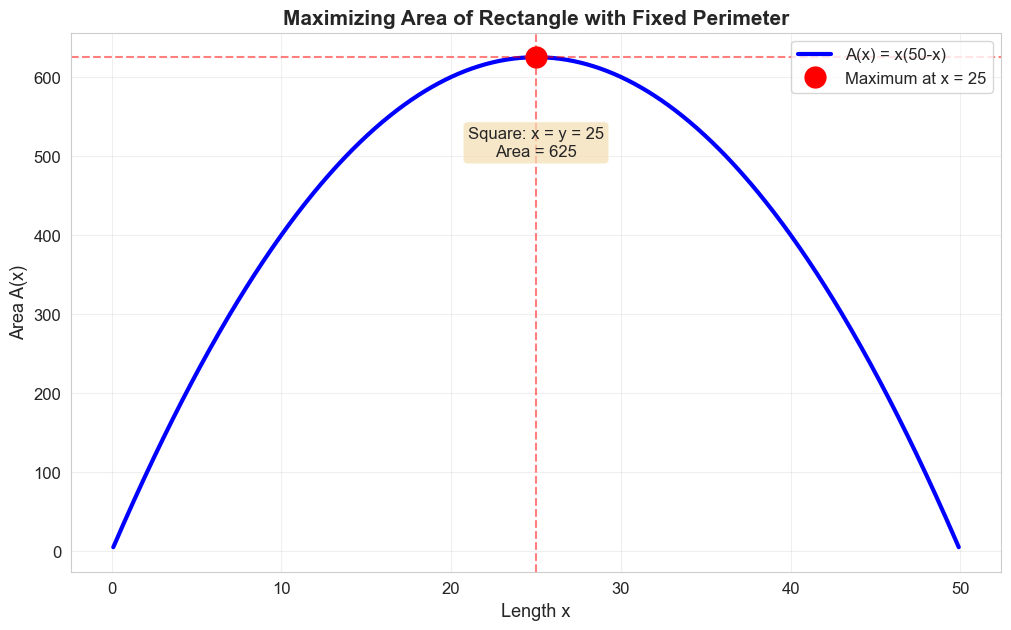

In [8]:
print("=" * 70)
print("OPTIMIZATION EXAMPLE")
print("=" * 70)

print("\nProblem: Find dimensions of a rectangle with perimeter 100")
print("         that maximizes area.")
print("-" * 70)

print("\nStep 1: Set up variables")
print("        Let x = length, y = width")
print("        Perimeter: 2x + 2y = 100")
print("        Area: A = xy")

print("\nStep 2: Express as function of one variable")
print("        From perimeter: y = 50 - x")
print("        Substitute into area: A(x) = x(50 - x) = 50x - x²")

print("\nStep 3: Find derivative")
print("        A'(x) = 50 - 2x")

print("\nStep 4: Find critical points")
print("        Set A'(x) = 0:")
print("        50 - 2x = 0")
print("        x = 25")

print("\nStep 5: Verify it's a maximum")
print("        A''(x) = -2 < 0  → concave down → MAXIMUM")

print("\nStep 6: Find dimensions")
print("        x = 25, y = 50 - 25 = 25")
print("        Maximum area = 25 × 25 = 625")

print("\nConclusion: Square gives maximum area!")

# Visualize
x_vals = np.linspace(0.1, 49.9, 1000)
A_vals = x_vals * (50 - x_vals)

plt.figure(figsize=(12, 7))
plt.plot(x_vals, A_vals, 'b-', linewidth=3, label='A(x) = x(50-x)')
plt.plot(25, 625, 'ro', markersize=15, label='Maximum at x = 25')
plt.axvline(x=25, color='r', linestyle='--', alpha=0.5)
plt.axhline(y=625, color='r', linestyle='--', alpha=0.5)
plt.xlabel('Length x', fontsize=13)
plt.ylabel('Area A(x)', fontsize=13)
plt.title('Maximizing Area of Rectangle with Fixed Perimeter', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.text(25, 500, 'Square: x = y = 25\nArea = 625', fontsize=12, ha='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
plt.show()

print("\n" + "=" * 70)

## 7. Key Takeaways

### Conceptual Understanding
- [ ] Derivative = instantaneous rate of change
- [ ] Derivative = slope of tangent line
- [ ] Where $f' > 0$, function increasing
- [ ] Where $f' < 0$, function decreasing
- [ ] Where $f' = 0$, potential max/min

### Essential Rules
- [ ] Power rule: $(x^n)' = nx^{n-1}$
- [ ] Product rule: $(fg)' = f'g + fg'$
- [ ] Quotient rule: $(f/g)' = (f'g - fg')/g^2$
- [ ] Chain rule: $(f \circ g)' = f'(g(x)) \cdot g'(x)$
- [ ] Implicit differentiation

### Common Derivatives to Memorize

| Function | Derivative |
|----------|------------|
| $c$ | $0$ |
| $x^n$ | $nx^{n-1}$ |
| $e^x$ | $e^x$ |
| $a^x$ | $a^x \ln a$ |
| $\ln x$ | $1/x$ |
| $\log_a x$ | $1/(x \ln a)$ |
| $\sin x$ | $\cos x$ |
| $\cos x$ | $-\sin x$ |
| $\tan x$ | $\sec^2 x$ |
| $\sec x$ | $\sec x \tan x$ |
| $\csc x$ | $-\csc x \cot x$ |
| $\cot x$ | $-\csc^2 x$ |

### Applications
- [ ] Finding tangent lines
- [ ] Finding critical points
- [ ] Determining intervals of increase/decrease
- [ ] Finding local maxima and minima
- [ ] Solving optimization problems
- [ ] Related rates

---

**Next Up**: Integration - the inverse of differentiation, and equally powerful!